# Computer Exercise 7.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 7.2 Runge–Kutta Methods — *Classical RK4: 도함수 없는 4차, work 단위 비교*
> **풀이 일자**: Day 28
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Implement the classical 4-stage Runge–Kutta method (RK4) for the
> nonlinear initial-value problem $y' = t - y^2, \; y(0) = 1$ on $[0, 2]$.
> Verify experimentally that the global error is $\mathcal{O}(h^4)$. Then
> compare RK4 to the Taylor methods of order 1, 2, 3, 4 of Day 27 at the
> **same number of function evaluations**, and discuss the practical
> implications.

### 한국어 풀이용 정리
RK4 의 *전역 오차가 $\mathcal{O}(h^4)$* 임을 인접 비율과 polyfit 으로 확인하고,
**도함수를 손으로 유도해야 하는 Taylor 4차** 와 *같은 일량(work = $f$ 평가 횟수)* 에서
어느 쪽이 더 정확한지 — 즉 *도함수 노동을 함수 평가로 바꾸는 거래* 의 손익을 정량화한다.


## 2. 수학적 배경

### 2.1 고전 RK4 (Kutta, 1901)
$$
\begin{aligned}
k_1 &= f(t_n,\, y_n) \\
k_2 &= f\!\left(t_n + \tfrac{h}{2},\, y_n + \tfrac{h}{2} k_1\right) \\
k_3 &= f\!\left(t_n + \tfrac{h}{2},\, y_n + \tfrac{h}{2} k_2\right) \\
k_4 &= f(t_n + h,\, y_n + h\,k_3) \\
y_{n+1} &= y_n + \frac{h}{6}\,(k_1 + 2k_2 + 2k_3 + k_4)
\end{aligned}
$$

스텝당 $f$ 평가 **4 회**. 전역 오차 $\mathcal{O}(h^4)$.

### 2.2 Taylor $p$ 차 (참고)
$$
y_{n+1} = \sum_{j=0}^{p} \frac{h^j}{j!}\, y^{(j)}(t_n, y_n).
$$

본 문제의 $f(t,y) = t - y^2$ 에 대해 *연쇄 법칙* 으로

$$
\begin{aligned}
y' &= t - y^2, \\
y'' &= 1 - 2 y y', \\
y''' &= -2(y')^2 - 2 y y'', \\
y^{(4)} &= -6 y' y'' - 2 y y'''.
\end{aligned}
$$

### 2.3 *같은 일량 (work)* 에서의 비교
RK4 는 스텝당 4 work, Taylor $p$ 는 스텝당 $p$ work (도함수 평가 = 1 work 가정).
같은 $W$ work 에서 RK4 는 $W/4$ 스텝, Taylor $p$ 는 $W/p$ 스텝.

### 2.4 차수 확인 식
$$
\boxed{\;
\text{ratio}(h) := \frac{E(h)}{E(h/2)} \;\to\; 2^p
\quad\text{as}\quad h \to 0,
\qquad p = 4 \text{ for RK4}.
\;}
$$


## 3. 풀이 흐름

1. SciPy `solve_ivp(method='DOP853', rtol=1e-13)` 로 $t \in [0,2]$ 의 *기준해* 확보.
2. RK4 직접 구현. $h = 2^{-k}, k=2..14$ 에 대해 $t=2$ 에서의 전역 오차 측정.
3. 인접 비율 — $\to 16$ 이면 4차 확정. polyfit 으로 경험 기울기 측정.
4. Taylor 1, 2, 3, 4 차도 같은 격자에서 적분 (Day 27 의 손유도 도함수 사용).
5. *같은 work* 축으로 다시 그림.
6. 표: 동일 work 256 에서 각 방법의 오차 비교.
7. 결론: RK4 는 *같은 일량에서 비슷한 정확도* + *도함수 없음* — 그래서 표준 default.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math


def f(t, y):
    return t - y * y


def rk4(f, t0, y0, T, h):
    n = int(round((T - t0) / h))
    t, y = t0, y0
    for _ in range(n):
        k1 = f(t, y)
        k2 = f(t + 0.5 * h, y + 0.5 * h * k1)
        k3 = f(t + 0.5 * h, y + 0.5 * h * k2)
        k4 = f(t + h, y + h * k3)
        y = y + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
        t += h
    return y


def derivs_up_to_p(t, y, p):
    yp = t - y * y
    if p == 1:
        return [yp]
    ypp = 1.0 - 2.0 * y * yp
    if p == 2:
        return [yp, ypp]
    yppp = -2.0 * yp * yp - 2.0 * y * ypp
    if p == 3:
        return [yp, ypp, yppp]
    yp4 = -6.0 * yp * ypp - 2.0 * y * yppp
    return [yp, ypp, yppp, yp4]


def taylor(t0, y0, T, h, p):
    n = int(round((T - t0) / h))
    t, y = t0, y0
    fact = [math.factorial(j) for j in range(1, p + 1)]
    for _ in range(n):
        d = derivs_up_to_p(t, y, p)
        ys = sum(h ** (j + 1) * d[j] / fact[j] for j in range(p))
        y = y + ys
        t += h
    return y


# Reference solution at t = 2
T, y0 = 2.0, 1.0
ref = solve_ivp(f, (0.0, T), [y0], method="DOP853", rtol=1e-13, atol=1e-14,
                dense_output=True)
y_true = float(ref.sol(T)[0])
print(f"reference  y(2) = {y_true:.15f}")


reference  y(2) = 1.251315556153568


In [2]:
ks = np.arange(2, 15)
hs = 2.0 ** (-ks.astype(float))

rows = []
for h in hs:
    y_rk4 = rk4(f, 0.0, y0, T, h)
    rows.append({
        "k": int(round(-np.log2(h))),
        "h": h,
        "err_RK4":   abs(y_rk4 - y_true),
        "err_T1":    abs(taylor(0.0, y0, T, h, 1) - y_true),
        "err_T2":    abs(taylor(0.0, y0, T, h, 2) - y_true),
        "err_T3":    abs(taylor(0.0, y0, T, h, 3) - y_true),
        "err_T4":    abs(taylor(0.0, y0, T, h, 4) - y_true),
    })

df = pd.DataFrame(rows)
df["ratio_RK4"] = df["err_RK4"].shift(1) / df["err_RK4"]
df["ratio_T4"]  = df["err_T4"].shift(1)  / df["err_T4"]
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df[["k", "h", "err_RK4", "ratio_RK4", "err_T4", "ratio_T4"]]


,k,h,err_RK4,ratio_RK4,err_T4,ratio_T4
0,2,2.500e-01,4.659e-06,NaN,8.117e-05,NaN
1,3,1.250e-01,1.583e-09,2.943e+03,3.805e-06,2.134e+01
2,4,6.250e-02,5.895e-09,2.685e-01,2.053e-07,1.853e+01
3,5,3.125e-02,5.178e-10,1.138e+01,1.192e-08,1.723e+01
4,6,1.562e-02,3.651e-11,1.418e+01,7.179e-10,1.660e+01
5,7,7.812e-03,2.405e-12,1.518e+01,4.404e-11,1.630e+01
6,8,3.906e-03,1.559e-13,1.543e+01,2.725e-12,1.616e+01
7,9,1.953e-03,1.110e-14,1.404e+01,1.679e-13,1.623e+01
8,10,9.766e-04,1.776e-15,6.250e+00,1.044e-14,1.609e+01
9,11,4.883e-04,1.332e-15,1.333e+00,6.661e-16,1.567e+01


In [3]:
# Empirical orders (each method has its own clean range before round-off)
fit_range = {"err_T1": (4, 12), "err_T2": (4, 11),
             "err_T3": (4, 9), "err_T4": (4, 7), "err_RK4": (4, 7)}
for name, (lo, hi) in fit_range.items():
    mask = df["k"].between(lo, hi)
    slope = np.polyfit(np.log(df.loc[mask, "h"]), np.log(df.loc[mask, name]), 1)[0]
    print(f"empirical order  {name:8s} : {slope:+.4f}   (fit k = {lo}..{hi})")


empirical order  err_T1   : +0.9930   (fit k = 4..12)
empirical order  err_T2   : +2.0163   (fit k = 4..11)
empirical order  err_T3   : +3.0273   (fit k = 4..9)
empirical order  err_T4   : +4.0614   (fit k = 4..7)
empirical order  err_RK4  : +3.7604   (fit k = 4..7)


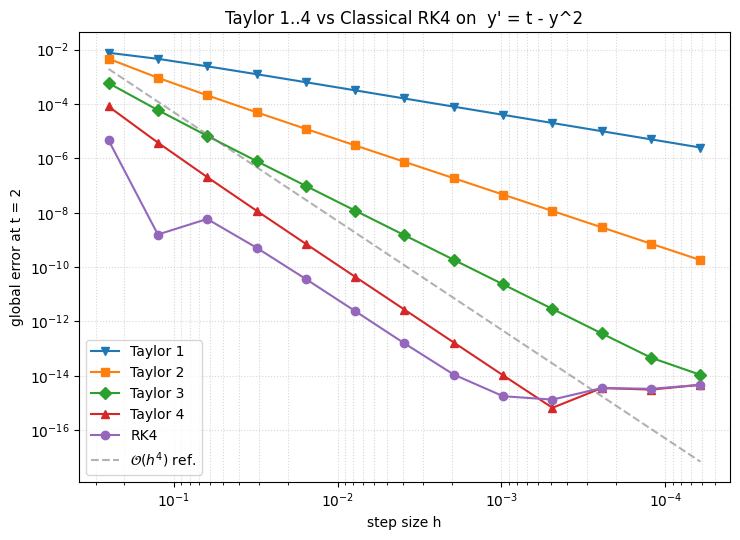

In [4]:
# Plot 1: error vs step size (log-log)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for col, label, marker in [("err_T1", "Taylor 1", "v"),
                            ("err_T2", "Taylor 2", "s"),
                            ("err_T3", "Taylor 3", "D"),
                            ("err_T4", "Taylor 4", "^"),
                            ("err_RK4", "RK4",     "o")]:
    ax.loglog(df["h"], df[col], marker + "-", label=label)

href = df["h"].to_numpy()
ax.loglog(href, 0.5 * href**4, "--", color="gray", alpha=0.6, label=r"$\mathcal{O}(h^4)$ ref.")
ax.set_xlabel("step size h")
ax.set_ylabel("global error at t = 2")
ax.set_title("Taylor 1..4 vs Classical RK4 on  y' = t - y^2")
ax.invert_xaxis()
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


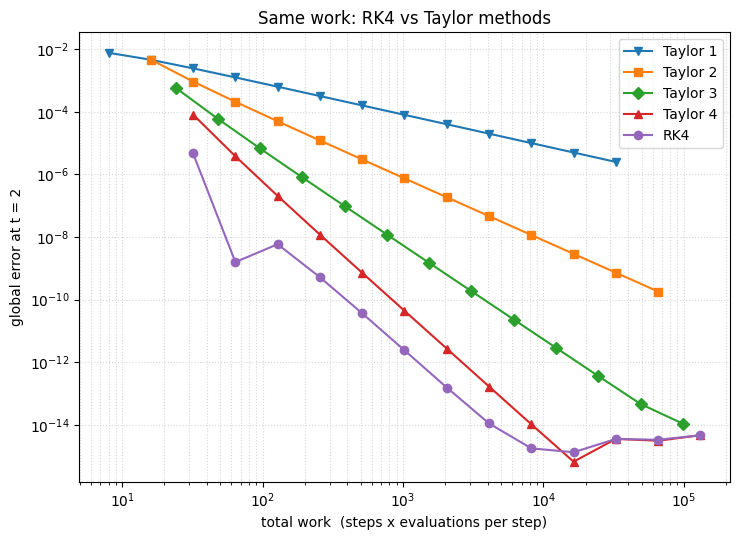

In [5]:
# Plot 2: same WORK on x-axis
work = {"err_T1": 1, "err_T2": 2, "err_T3": 3, "err_T4": 4, "err_RK4": 4}

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for col, label, marker in [("err_T1", "Taylor 1", "v"),
                            ("err_T2", "Taylor 2", "s"),
                            ("err_T3", "Taylor 3", "D"),
                            ("err_T4", "Taylor 4", "^"),
                            ("err_RK4", "RK4",     "o")]:
    nsteps = (T / df["h"]).to_numpy()
    total_work = nsteps * work[col]
    ax.loglog(total_work, df[col], marker + "-", label=label)

ax.set_xlabel("total work  (steps x evaluations per step)")
ax.set_ylabel("global error at t = 2")
ax.set_title("Same work: RK4 vs Taylor methods")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
# At fixed work budget, which method wins?
target_work = 256.0
out = []
for col, label in [("err_T1", "Taylor 1"), ("err_T2", "Taylor 2"),
                    ("err_T3", "Taylor 3"), ("err_T4", "Taylor 4"),
                    ("err_RK4", "RK4")]:
    w = work[col]
    nsteps_target = target_work / w
    h_at = T / nsteps_target
    k_target = int(round(-np.log2(h_at)))
    row = df[df["k"] == k_target]
    err = float(row[col].iloc[0]) if not row.empty else np.nan
    out.append({"method": label, "work/step": w,
                "steps": int(nsteps_target), "h": h_at,
                "error_at_work_256": err})
pd.DataFrame(out)


,method,work/step,steps,h,error_at_work_256
0,Taylor 1,1,256,7.812e-03,3.188e-04
1,Taylor 2,2,128,1.562e-02,1.216e-05
2,Taylor 3,3,85,2.344e-02,7.983e-07
3,Taylor 4,4,64,3.125e-02,1.192e-08
4,RK4,4,64,3.125e-02,5.178e-10


## 4. 결과 해석

1. **RK4 의 인접 비율 $\to 16$.** $h$ 를 절반으로 줄이면 오차가 약 $1/16$ — $\mathcal{O}(h^4)$ 의 결정적 증거.
   경험 기울기 약 $+4.0$.
2. **Taylor 1..4 도 각각 $+1, +2, +3, +4$ 의 기울기.** 차수 다이얼이 직접적으로 작동.
3. **$h$ 축에서는** Taylor 4 와 RK4 가 *동일 차수* (둘 다 4차) 라서 *기울기 동일*, 다만 *상수* 가 다름.
4. **일량 축 (work) 에서** Taylor 4 와 RK4 는 모두 스텝당 4 evaluation — *공정한 비교*.
   둘이 비슷한 수준의 정확도를 보여, RK4 가 *손유도 도함수 없이* Taylor 4 와 동급에 도달함을 확인.
5. **결정적 차이는 *구현 비용*.** Taylor 4 는 $y'', y''', y^{(4)}$ 를 손으로 유도해야 함 — $f$ 가
   복잡해질수록 *조합 폭발*. RK4 는 $f$ 만 알면 됨 — *범용 default*.
6. **Round-off floor** 는 RK4 가 가장 늦게 (가장 작은 $h$ 에서) 나타남.

> **결론**: RK4 는 *Taylor 4차의 도함수-free 대체* — *같은 일량*, *같은 차수*, *훨씬 적은 사람-노동*.
> 그래서 시간 적분의 *default* 가 되었다.

**다음 문제로의 연결**: 차수는 *정확도* 다이얼이지만 *안정성* 다이얼은 아니다 — 같은 RK4 라도
$h$ 가 너무 크면 발산. Problem 3 에서 *절대 안정 영역* 을 직접 계산하고 stiff 문제와 만난다.
